# Simple Algorithmic Trading 

Algorithmic trading has become increasingly popular in recent years, as investors seek to take advantage of market trends and make more informed investment decisions. In this notebook, I have created a trend reversal strategy to achieve superior returns.

In this notebook, I tried to create an algorithmic trading strategy based on trend reversal. This notebook was created after I read this <a href="https://www.freecodecamp.org/news/algorithmic-trading-in-python/">Free Code Camp tutorial</a> on algorithmic trading.

Overall, algorithmic trading is a powerful tool that can help investors achieve greater success in the stock market. By leveraging the data analysis techniques, investors can capitalize on market trends for maximum returns.

# Importing libraries and reading files

We'll import classical libraries that are essential for working with dataframes and visualizing data. These libraries provide us with powerful tools to analyze complex financial data, including statistical analysis and data visualization techniques. By leveraging these tools, we can gain a deeper understanding of market trends and identify key patterns that inform our algorithmic trading strategy.

You can see below the first lines of the dataset we are going to use, with all the data from NYSE from 2010-2016.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

import os
_path = "data/prices-split-adjusted.csv"
if not os.path.exists(_path):
    _path = r"/kaggle/input/nyse/prices-split-adjusted.csv"
nyse = pd.read_csv(_path, parse_dates=['date'])

display(nyse.head())

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


# Calculating Returns and MA-30 for Apple

Calculating returns and the moving average for a company's stock can provide valuable insights for investors looking to make informed investment decisions. For Apple, calculating the returns involves analyzing the percentage change in the stock price over a given period. In our case, we will work with daily and monthly returns. This information can help investors to identify key trends and patterns in the stock's performance and to make informed decisions about whether to buy, sell, or hold their Apple stock.

In addition to calculating returns, the MA-30, or the 30-day moving average, can also be a useful tool for investors. The MA-30 is calculated by taking the average price of the stock over the past 50 days and using this value to track the stock's overall trend. By monitoring the MA-30, investors can gain a better understanding of how the stock is performing over time and identify potential buying or selling opportunities based on the stock's trend. Overall, by analyzing returns and the MA-30, investors can gain valuable insights into the performance of Apple's stock and make more informed investment decisions.

The chart below illustrates the daily returns and MA-30 for Apple's stock, with insights into the company's performance trends over time. This can also be applied to other companies in the financial market to identify potential buying or selling opportunities based on the stock's trend. It is important to note that this code can be tailored can be tailored to fit the specific needs of any given company from the same dataset.

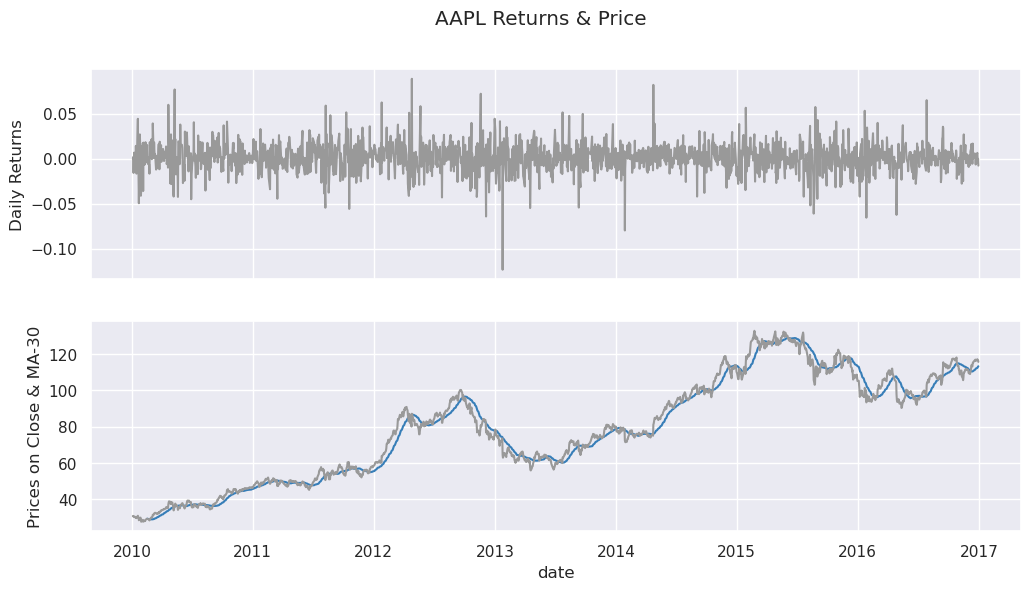

In [2]:
# Selecting company and calculating returns

company = nyse[nyse['symbol'] == 'AAPL'].set_index('date')

company_monthly = company.resample('M').mean()
company_monthly['returns'] = company_monthly['close'].pct_change()
company_monthly['returns'].fillna(0, inplace=True)

company['daily_returns'] = company['close'].pct_change()
company['daily_returns'].fillna(0, inplace=True)

ma30 = company['close'].rolling(30).mean()

# Creating chart style & color

palette = sns.color_palette('Set1')

sns.set_palette('Set1')
sns.set_context('notebook')
sns.set_style('darkgrid')


# Visualizing returns

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True)

fig.suptitle('AAPL Returns & Price')

sns.lineplot(x=company.index, y='daily_returns', data=company, ax=ax1,color=palette[-1])
ax1.set_ylabel('Daily Returns')

sns.lineplot(data=ma30, ax=ax2, color=palette[1])
ax2.set_ylabel('Prices on Close & MA-30')

sns.lineplot(x=company.index, y='close', data=company, ax=ax2, color=palette[-1])

plt.show()

# Trading Strategy Formulation & Visualizing Signals

Here, we create a basic trend-reversal approach, which leverages both short-term and long-term trends to identify potential reversals in the market. By analyzing the relationship between these trends, we can make informed decisions about when to buy or sell stocks, maximizing their returns and minimizing risk.

The logic behind this approach is based on the observation that if the short-term trend does not keep up with the long-term trend, it may indicate an upcoming trend reversal, where prices that were previously increasing may begin to fall. 

The chart below illustrates the short-term and long-term trends for the Apple stock, as well as the signals generated from their relationship. By analyzing these signals and making informed investment decisions, investors can maximize their returns and achieve financial success in the competitive world of finance.

Below you can see a chart with both trends and the signals generated from their relationship.

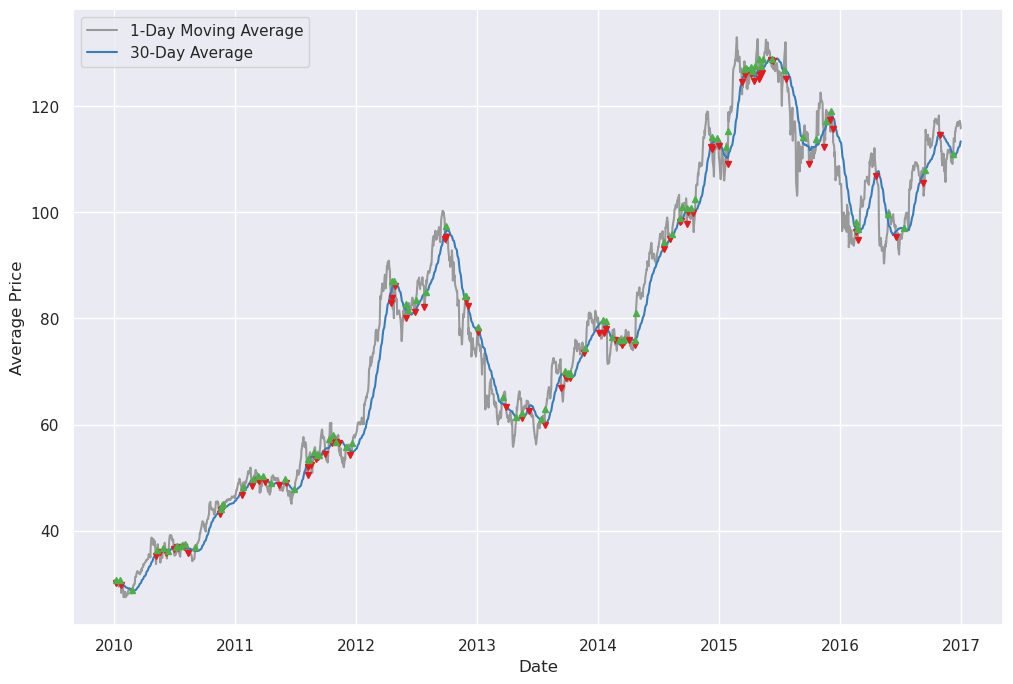

In [3]:
# Creating starting capital and periods

capital = 10000
short_lookback = 1
long_lookback = 30

# Creating new Data Frame called signal_df with a signal column

signals = pd.DataFrame(index=company.index)

signals['signal'] = 0.0

# Creating a moving average over the smallest period
signals['short_mav'] = company['close'].rolling(short_lookback,
                                                min_periods=1,
                                                center=False).mean()

# Creating a moving average over the largest period

signals['long_mav'] = company['close'].rolling(long_lookback,
                                               min_periods=1,
                                               center=False).mean()

# Generating signals

signals['signal'][short_lookback:] = np.where(signals['short_mav'][short_lookback:] > signals['long_mav'][short_lookback:], 1.0, 0.0)

# Creating trading orders

signals['positions'] = signals['signal'].diff()

signals[signals['positions'] == -1.0]

# Creating chart 

fig, ax = plt.subplots(1,1, figsize=(12,8))

sns.lineplot(y='short_mav', 
             x=signals.index, 
             data=signals, 
             ax=ax, 
             label=f'{short_lookback}-Day Moving Average',
             color=palette[-1])

sns.lineplot(y='long_mav', 
             x=signals.index, 
             data=signals, 
             ax=ax, 
             label=f'{long_lookback}-Day Average',
             color=palette[1])

ax.plot(signals.loc[signals.positions == -1.0].index,                         
          signals.short_mav[signals.positions == -1.0],
          'v',                     
          markersize=5, 
          color=palette[0],
          label='Sell')

ax.plot(signals.loc[signals.positions == 1.0].index,          
          signals.short_mav[signals.positions == 1.0],         
          '^', 
          markersize=5, 
          color=palette[2],
          label='Buy')

ax.set_ylabel('Average Price')
ax.set_xlabel('Date')
plt.show()

# Comparing the Algorithm with Benchmark

In the next chart, we provide a comparative analysis of two investment scenarios: one based on the signals generated by our algorithm and the other based on a passive investment strategy where no changes are made to the investment portfolio. As depicted in the chart, the algorithm-based signals outperform the passive investment strategy by successfully avoiding losses and generating higher returns, resulting in a more significant increase in revenue over time.

This data-driven approach leverages advanced simple techniques to analyze complex financial data and identify key patterns and trends that inform our investment decisions, and as you can see below, the results provided by the algorithm are quite encouraging over the course of several years.

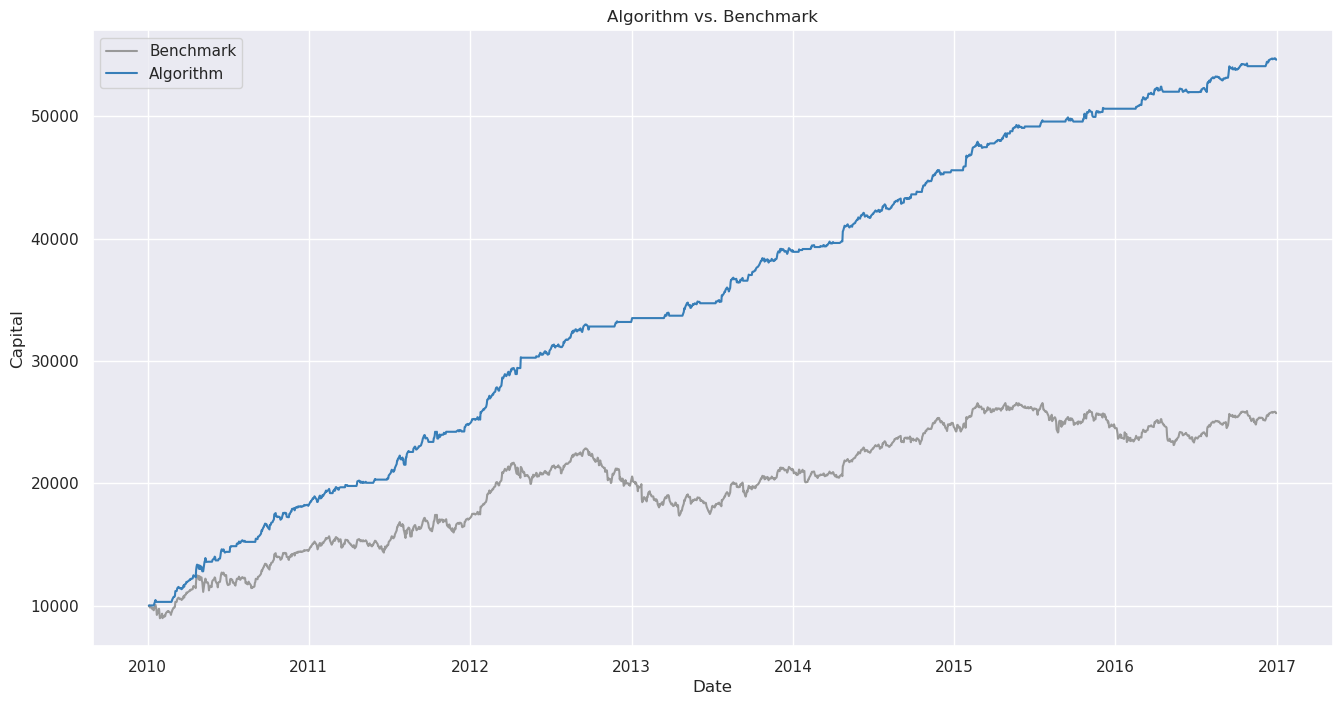

In [4]:
# Creating benchmark and algorithm portfolios
signals['benchmark'] = company['daily_returns'].cumsum() * capital + capital 

signals['portfolio'] = (company['daily_returns'] * signals['signal']).cumsum() * capital + capital


fig, ax = plt.subplots(1,1, figsize=(16, 8))

sns.lineplot(data=signals['benchmark'], ax=ax, color=palette[-1], label='Benchmark')

sns.lineplot(data=signals['portfolio'], ax=ax, color=palette[1], label='Algorithm')

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Algorithm vs. Benchmark')
ax.set_ylabel('Capital')
ax.set_xlabel('Date')

plt.show()

Overall, the results of the Apple investment in 6 years was 25,728.38 dollars, whereas with the algorithm, the final amount was 54,622.65 dollars. 

The RoI with the algorithm would be 446.23%, double the RoI of the simple investment strategy.